In [1]:
import pandas as pd

df = pd.read_csv(
    "../Data/raw/title.basics.tsv/title.basics.tsv",
    sep="\t",
    low_memory=False
    
)

df.tail()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
12660902,tt9916848,tvEpisode,Episode #3.17,Episode #3.17,0,2009,\N,\N,Drama
12660903,tt9916850,tvEpisode,Episode #3.19,Episode #3.19,0,2010,\N,\N,Drama
12660904,tt9916852,tvEpisode,Episode #3.20,Episode #3.20,0,2010,\N,\N,Drama
12660905,tt9916856,short,The Wind,The Wind,0,2015,\N,27,Short
12660906,tt9916880,tvEpisode,Horrid Henry Knows It All,Horrid Henry Knows It All,0,2014,\N,10,"Adventure,Animation,Comedy"


In [2]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 12660907 entries, 0 to 12660906
Data columns (total 9 columns):
 #   Column          Dtype
---  ------          -----
 0   tconst          str  
 1   titleType       str  
 2   primaryTitle    str  
 3   originalTitle   str  
 4   isAdult         int64
 5   startYear       str  
 6   endYear         str  
 7   runtimeMinutes  str  
 8   genres          str  
dtypes: int64(1), str(8)
memory usage: 869.4 MB


(12660907, 9)

In [3]:
df.isnull().sum()


tconst             0
titleType          0
primaryTitle      25
originalTitle     25
isAdult            0
startYear          0
endYear            0
runtimeMinutes     0
genres            31
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df["titleType"].value_counts()

titleType
tvEpisode       9785156
short           1145544
movie            752602
video            328412
tvSeries         302613
tvMovie          155474
tvMiniSeries      71699
tvSpecial         58730
videoGame         49645
tvShort           11031
tvPilot               1
Name: count, dtype: int64

In [6]:
df["isAdult"].value_counts()

isAdult
0       12248350
1         412526
2023           7
1979           4
2019           3
2024           3
2025           3
2020           2
2022           2
2018           2
1981           1
2017           1
2014           1
2013           1
2005           1
Name: count, dtype: int64

In [7]:
(df == "\\N").sum()

tconst                   0
titleType                0
primaryTitle             0
originalTitle            0
isAdult                  0
startYear          1476631
endYear           12501436
runtimeMinutes     8119067
genres              539518
dtype: int64

In [5]:
df_movies = df[df["titleType"] == "movie"].copy()
print(df_movies.shape)

(752602, 9)


In [9]:
percentage = (len(df_movies) / len(df)) * 100
print(f"Movies make up {percentage:.2f}% of the dataset.")

Movies make up 5.94% of the dataset.


In [6]:

df_movies = df_movies.dropna(subset=["primaryTitle", "originalTitle"])
df_movies.isnull().sum()

tconst            0
titleType         0
primaryTitle      0
originalTitle     0
isAdult           0
startYear         0
endYear           0
runtimeMinutes    0
genres            0
dtype: int64

In [11]:
df_movies.duplicated().sum()

np.int64(0)

In [12]:
df_movies["startYear"].value_counts().head(10)

startYear
\N      113333
2024     21335
2023     21142
2022     21030
2025     21002
2018     19545
2019     19532
2021     19268
2017     19251
2016     18784
Name: count, dtype: int64

In [13]:
percentage2 = (len(df_movies[df_movies["startYear"] == "\\N"]) / len(df_movies)) * 100
print(f"Movies with no start year make up {percentage2:.2f}% of the dataset.")

Movies with no start year make up 15.06% of the dataset.


In [7]:
import numpy as np
df_movies.replace("\\N", np.nan, inplace=True)
df_movies.isnull().sum().sort_values(ascending=False)

endYear           752599
runtimeMinutes    278117
startYear         113333
genres             77962
tconst                 0
isAdult                0
originalTitle          0
primaryTitle           0
titleType              0
dtype: int64

In [8]:
df_movies.drop(columns="endYear", inplace=True)
df_movies[df_movies["genres"].isna()].head(10)

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres
498,tt0000502,movie,Bohemios,Bohemios,0,1905,100,NaN
828,tt0000838,movie,A Cultura do Cacau,A Cultura do Cacau,0,1909,NaN,NaN
832,tt0000842,movie,De Garraf a Barcelona,De Garraf a Barcelona,0,1909,NaN,NaN
836,tt0000846,movie,Un día en Xochimilco,Un día en Xochimilco,0,1909,NaN,NaN
840,tt0000850,movie,Los dos hermanos,Los dos hermanos,0,1909,NaN,NaN
849,tt0000859,movie,Fabricación del corcho en Sant Feliu de Guixols,Fabricación del corcho en Sant Feliu de Guixols,0,1909,NaN,NaN
852,tt0000862,movie,Faldgruben,Faldgruben,0,1909,NaN,NaN
857,tt0000867,movie,Fiesta de toros,Fiesta de toros,0,1909,NaN,NaN
858,tt0000868,movie,Fiestas de Santa Lucía - Belenes,Fiestas de Santa Lucía - Belenes,0,1909,NaN,NaN
859,tt0000869,movie,Fiestas en La Garriga,Fiestas en La Garriga,0,1909,NaN,NaN


In [9]:
df_movies = df_movies.dropna(subset=["genres"])
df_movies["genres"].value_counts().head(30)

genres
Drama                    137956
Documentary              115775
Comedy                    51233
Horror                    21399
Thriller                  18157
Action                    17254
Comedy,Drama              15115
Drama,Romance             14456
Romance                    8760
Comedy,Romance             8154
Adult                      6744
Crime,Drama                6421
Comedy,Drama,Romance       6181
Crime                      5858
Drama,Thriller             5402
Sci-Fi                     5146
Drama,Western              5093
Adventure                  5035
Documentary,Music          4836
Action,Drama               4637
Action,Crime,Drama         4621
Horror,Thriller            4512
Family                     4454
Animation                  3907
Biography,Documentary      3799
Fantasy                    3427
Music                      3390
Biography                  3085
Crime,Drama,Thriller       2984
Drama,War                  2850
Name: count, dtype: int64

In [10]:
df_movies['genres'].nunique()

1461

In [11]:
unique_genres = set()

for genres in df_movies["genres"]:
    unique_genres.update(genres.split(","))

print(sorted(unique_genres))
print(f"Number of unique genres: {len(unique_genres)}")

['Action', 'Adult', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'Game-Show', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News', 'Reality-TV', 'Romance', 'Sci-Fi', 'Sport', 'Talk-Show', 'Thriller', 'War', 'Western']
Number of unique genres: 27


In [12]:
genre_counts = (
    df_movies["genres"]
    .str.get_dummies(sep=",")
    .sum()
    .sort_values(ascending=False)
)
print(genre_counts)

Drama          274839
Documentary    149460
Comedy         125202
Action          62202
Romance         54137
Thriller        54037
Horror          47380
Crime           43665
Adventure       32130
Mystery         20663
Biography       20217
Family          20216
Fantasy         18384
History         16825
Sci-Fi          16605
Music           16285
Animation       11427
Musical         11254
War             10165
Sport            9149
Adult            9121
Western          8139
News             1502
Film-Noir         875
Reality-TV        599
Talk-Show         222
Game-Show          13
dtype: int64


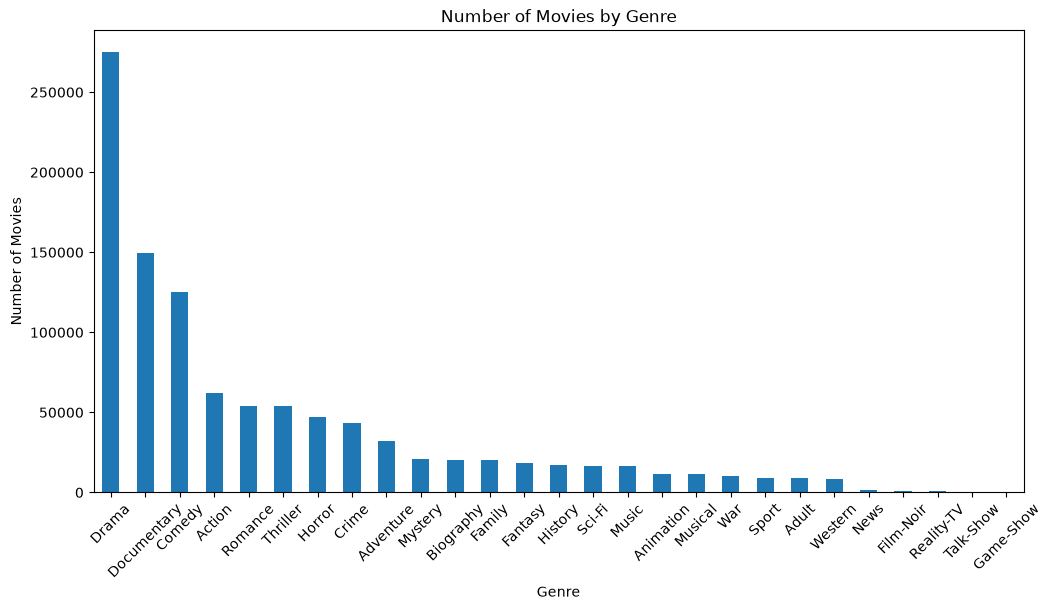

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns 
genre_counts.plot(kind="bar", figsize=(12,6))
plt.title("Number of Movies by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)

plt.show()

In [14]:
df_movies['runtimeMinutes'].describe()

count     447899
unique       530
top           90
freq       28967
Name: runtimeMinutes, dtype: object

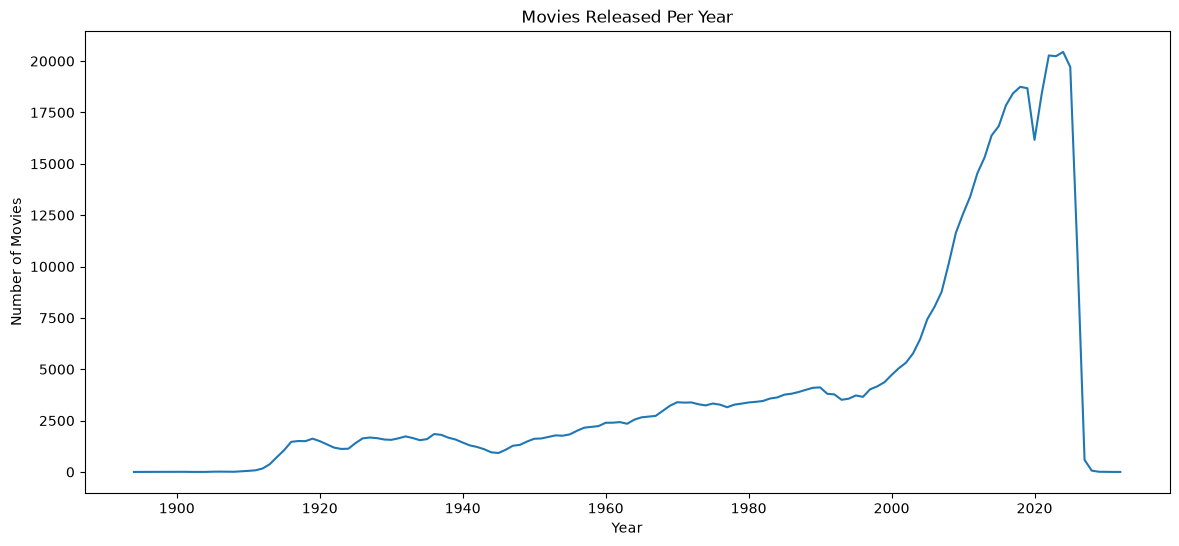

In [15]:
df_movies["startYear"] = pd.to_numeric(df_movies["startYear"], errors="coerce")
movies_per_year = (
    df_movies["startYear"]
    .value_counts()
    .sort_index()
)

movies_per_year.plot(figsize=(14,6))

plt.title("Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

In [16]:
print(df_movies["startYear"].min())
print(df_movies["startYear"].max())

1894.0
2032.0


In [17]:
df_ratings = pd.read_csv(
    "../Data/raw/title.ratings.tsv/title.ratings.tsv",
    sep="\t"
)
df_ratings.head()

,tconst,averageRating,numVotes
0,tt0000001,5.7,2219
1,tt0000002,5.4,322
2,tt0000003,6.4,2361
3,tt0000004,5.1,193
4,tt0000005,6.2,3073


In [18]:
df_ratings.info
df_ratings.columns

Index(['tconst', 'averageRating', 'numVotes'], dtype='str')

In [26]:
df_ratings.isnull().sum()

tconst           0
averageRating    0
numVotes         0
dtype: int64

In [27]:
df_ratings['tconst'].isnull().sum()

np.int64(0)

In [19]:
df_movies= df_movies.merge(
    df_ratings,
    on="tconst",
    how="left"
)


In [21]:
# df_movies.drop(columns=["averageRating_y","numVotes_y"], inplace=True)
df_movies.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894.0,45,Romance,5.3,233.0
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897.0,100,"Documentary,News,Sport",5.3,605.0
2,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906.0,70,"Action,Adventure,Biography",6.0,1077.0
3,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907.0,90,Drama,4.8,40.0
4,tt0000615,movie,Robbery Under Arms,Robbery Under Arms,0,1907.0,NaN,Drama,3.4,36.0


In [22]:

df_movies.rename(columns={
    "averageRating_x": "Average Rating",
    "numVotes_x": "Number of Votes"
}, inplace=True)


In [23]:
df_movies.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894.0,45,Romance,5.3,233.0
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897.0,100,"Documentary,News,Sport",5.3,605.0
2,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906.0,70,"Action,Adventure,Biography",6.0,1077.0
3,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907.0,90,Drama,4.8,40.0
4,tt0000615,movie,Robbery Under Arms,Robbery Under Arms,0,1907.0,NaN,Drama,3.4,36.0


In [ ]:
df_movies[["Average Rating", "Number of Votes"]].isnull().sum()

Average Rating     338229
Number of Votes    338229
dtype: int64

In [24]:
top_rated=(
    df_movies[df_movies['Number of Votes']>10000]
    .sort_values("Average Rating", ascending=False)
    [["primaryTitle", "startYear", "Average Rating", "Number of Votes"]]
    .head(10)
)

top_rated


KeyError: 'Number of Votes'

In [ ]:
most_popular=(
    df_movies.sort_values("Number of Votes",ascending=False)
 [["primaryTitle", "startYear", "Average Rating", "Number of Votes"]]
    .head(10)
)
most_popular


,primaryTitle,startYear,Average Rating,Number of Votes
72008,The Shawshank Redemption,1994.0,9.3,3209364.0
176958,The Dark Knight,2008.0,9.1,3190941.0
264973,Inception,2010.0,8.8,2836660.0
84322,Fight Club,1999.0,8.8,2631387.0
185626,Interstellar,2014.0,8.7,2561503.0
71260,Forrest Gump,1994.0,8.8,2511459.0
71861,Pulp Fiction,1994.0,8.8,2448961.0
82505,The Matrix,1999.0,8.7,2260600.0
46451,The Godfather,1972.0,9.2,2238260.0
76790,The Lord of the Rings: The Fellowship of the Ring,2001.0,8.9,2218754.0


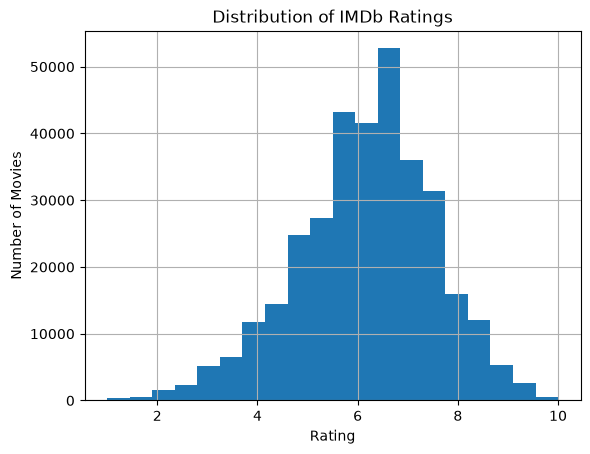

In [ ]:
import matplotlib.pyplot as plt

df_movies["Average Rating"].hist(bins=20)

plt.title("Distribution of IMDb Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")
plt.show()

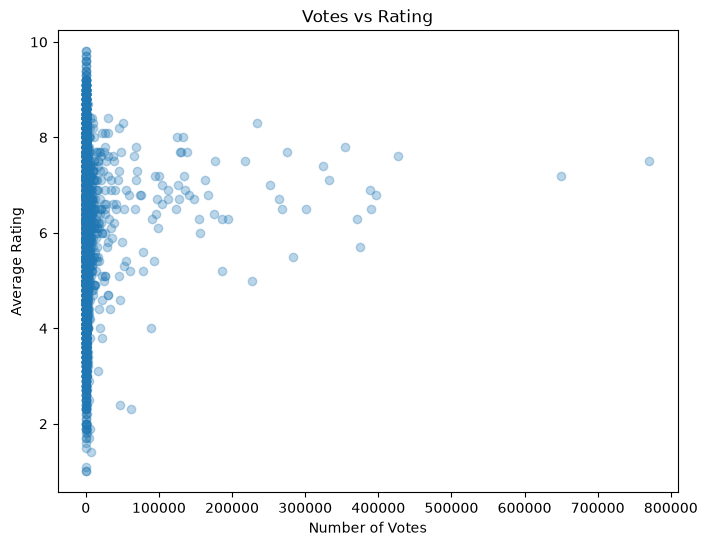

In [ ]:
sample = df_movies.sample(10000, random_state=42)

plt.figure(figsize=(8,6))
plt.scatter(sample["Number of Votes"], sample["Average Rating"], alpha=0.3)

plt.xlabel("Number of Votes")
plt.ylabel("Average Rating")
plt.title("Votes vs Rating")
plt.show()

##This tells you the average IMDb rating by genre.

In [ ]:
genre_df = (
    df_movies.assign(genres=df_movies["genres"].str.split(","))
    .explode("genres")
)

genre_ratings = (
    genre_df.groupby("genres")["Average Rating"]
    .mean()
    .sort_values(ascending=False)
)

genre_ratings

genres
Game-Show      7.433333
News           7.174601
Documentary    7.174541
Biography      6.912359
Talk-Show      6.878571
Music          6.800684
History        6.754273
Sport          6.627324
Reality-TV     6.479208
Film-Noir      6.458286
War            6.360206
Animation      6.272775
Drama          6.183067
Musical        6.146536
Family         6.144123
Romance        6.064665
Crime          5.959939
Comedy         5.876820
Adventure      5.840826
Fantasy        5.818536
Western        5.801150
Mystery        5.790884
Action         5.722299
Adult          5.633085
Thriller       5.569710
Sci-Fi         5.304499
Horror         4.961565
Name: Average Rating, dtype: float64

In [ ]:
df_movies.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,Average Rating,Number of Votes
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894.0,45,Romance,5.3,233.0
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897.0,100,"Documentary,News,Sport",5.3,605.0
2,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906.0,70,"Action,Adventure,Biography",6.0,1077.0
3,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907.0,90,Drama,4.8,40.0
4,tt0000615,movie,Robbery Under Arms,Robbery Under Arms,0,1907.0,NaN,Drama,3.4,36.0


In [ ]:
df_crew = pd.read_csv(
    "../Data/raw/title.crew.tsv/title.crew.tsv",
    sep="\t"
)
df_crew.head()
df_crew.columns

Index(['tconst', 'directors', 'writers'], dtype='str')

In [ ]:
df_crew.isnull().sum()
df_crew.replace("\\N", pd.NA, inplace=True)

,tconst,directors,writers
0,tt0000001,nm0005690,NaN
1,tt0000002,nm0721526,NaN
2,tt0000003,nm0721526,nm0721526
3,tt0000004,nm0721526,NaN
4,tt0000005,nm0005690,NaN
...,...,...,...
12660902,tt9916848,nm1485677,"nm9187127,nm1485677,nm9826385,nm9299459,nm1628284"
12660903,tt9916850,nm1485677,"nm9187127,nm1485677,nm9826385,nm1628284"
12660904,tt9916852,nm1485677,"nm9187127,nm1485677,nm9826385,nm9299459,nm1628284"
12660905,tt9916856,nm10538645,nm6951431


In [ ]:
df_crew["tconst"].duplicated().sum()

np.int64(0)

In [ ]:
df_movies = df_movies.merge(
    df_crew,
    on="tconst",
    how="left"
)
# df_movies.drop(columns=["directors_y","writers_y"], inplace=True)


df_movies.head()

MergeError: Passing 'suffixes' which cause duplicate columns {'directors_x', 'writers_x'} is not allowed.

In [ ]:
df_movies.drop(columns=["directors_x","writers_x"], inplace=True)
df_movies.head()



,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,Average Rating,Number of Votes,directors,writers
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894.0,45,Romance,5.3,233.0,nm0085156,nm0085156
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897.0,100,"Documentary,News,Sport",5.3,605.0,nm0714557,NaN
2,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906.0,70,"Action,Adventure,Biography",6.0,1077.0,nm0846879,nm0846879
3,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907.0,90,Drama,4.8,40.0,nm0141150,nm0141150
4,tt0000615,movie,Robbery Under Arms,Robbery Under Arms,0,1907.0,NaN,Drama,3.4,36.0,nm0533958,"nm0092809,nm0533958"


In [ ]:
df_names = pd.read_csv(
    "../Data/raw/name.basics.tsv/name.basics.tsv",
    sep="\t"
)
df_names.head()
df_names.columns

Index(['nconst', 'primaryName', 'birthYear', 'deathYear', 'primaryProfession',
       'knownForTitles'],
      dtype='str')

##Before converting them to names...

Let's think efficiently.

name.basics.tsv.gz contains millions of people. If we merge the whole thing blindly, it will be slow and consume a lot of memory.

Instead, we'll extract only the IDs we actually need.

In [ ]:
director_ids = (
    df_movies["directors"]
    .dropna()
    .str.split(",")
    .explode()
    .unique()
)

In [ ]:
writer_ids = (
    df_movies["writers"]
    .dropna()
    .str.split(",")
    .explode()
    .unique()
)

In [ ]:
people_ids = set(director_ids).union(set(writer_ids))

print(f"Unique people IDs: {len(people_ids)}")

Unique people IDs: 476010


In [ ]:
df_names = pd.read_csv(
    "../Data/raw/name.basics.tsv/name.basics.tsv",
    sep="\t"
)
df_names.head()
df_names.columns

Index(['nconst', 'primaryName', 'birthYear', 'deathYear', 'primaryProfession',
       'knownForTitles'],
      dtype='str')

In [ ]:
df_names.replace("\\N", pd.NA, inplace=True)

,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles
0,nm0000001,Fred Astaire,1899,1987,"actor,miscellaneous,producer","tt0072308,tt0050419,tt0027125,tt0025164"
1,nm0000002,Lauren Bacall,1924,2014,"actress,miscellaneous,soundtrack","tt0037382,tt0075213,tt0038355,tt0117057"
2,nm0000003,Brigitte Bardot,1934,2025,"actress,music_department,producer","tt0057345,tt0049189,tt0056404,tt0054452"
3,nm0000004,John Belushi,1949,1982,"actor,writer,music_department","tt0072562,tt0077975,tt0080455,tt0078723"
4,nm0000005,Ingmar Bergman,1918,2007,"writer,director,actor","tt0050986,tt0083922,tt0069467,tt0050976"
...,...,...,...,...,...,...
15507055,nm9993714,Romeo del Rosario,NaN,NaN,"animation_department,art_department","tt11657662,tt14069590,tt2455546"
15507056,nm9993716,Essias Loberg,NaN,NaN,NaN,NaN
15507057,nm9993717,Harikrishnan Rajan,NaN,NaN,cinematographer,tt8736744
15507058,nm9993718,Aayush Nair,NaN,NaN,cinematographer,tt8736744


In [2]:
df_names = df_names[df_names["nconst"].isin(people_ids)]

NameError: name 'df_names' is not defined

In [ ]:
name_map = df_names.set_index("nconst")["primaryName"].to_dict()

##This will basically help us to split the comma from between the names of different directors to prevent every set of different actors group as unique it is better this way to avoid any sort of confusion


In [ ]:
df_movies["director_names"] = (
    df_movies["directors"]
    .str.split(",")
    .apply(lambda ids: [name_map.get(i, i) for i in ids] if isinstance(ids, list) else None)
)

In [ ]:
name_map_2 = df_names.set_index("nconst")["primaryName"].to_dict()
df_movies["writer_names"] = (
    df_movies["writers"]
    .str.split(",")
    .apply(lambda ids: [name_map.get(i, i) for i in ids] if isinstance(ids, list) else None)
)


In [ ]:
df_movies["directors"].sample(10)
def map_people(ids):
    if pd.isna(ids):
        return None

    names = []

    for person_id in str(ids).split(","):
        name = name_map.get(person_id)

        if pd.notna(name):
            names.append(str(name))
        else:
            names.append(person_id)

    return ", ".join(names)
df_movies["director_names"] = df_movies["directors"].apply(map_people)
df_movies["writer_names"] = df_movies["writers"].apply(map_people)
df_movies['director_names'].head()

0     Alexander Black
1     Enoch J. Rector
2        Charles Tait
3        Michel Carré
4    Charles MacMahon
Name: director_names, dtype: str

In [ ]:
df_principals = pd.read_csv(
    "../Data/raw/title.principals_2.tsv/title.principals.tsv",
    sep="\t"
)
df_principals.head()
df_principals.columns

Index(['tconst', 'ordering', 'nconst', 'category', 'job', 'characters'], dtype='str')

In [ ]:
df_principals = df_principals[
    df_principals["category"].isin(["actor", "actress"])
]

In [ ]:
df_principals = df_principals[
    df_principals["ordering"] <= 3
]

In [ ]:
df_principals["actor_name"] = df_principals["nconst"].map(name_map)

In [ ]:
movie_ids = set(df_movies["tconst"])

df_principals = df_principals[
    df_principals["tconst"].isin(movie_ids)
]

In [1]:
actors = (
    df_principals
    .dropna(subset=["actor_name"])
    .groupby("tconst", sort=False)["actor_name"]
    .agg(", ".join)
    .reset_index(name="actors")
)

NameError: name 'df_principals' is not defined

In [ ]:
df_movies = df_movies.merge(
    actors,
    on="tconst",
    how="left"
)

In [ ]:
df_movies.rename(
    columns={"actor_name": "actors"},
    inplace=True
)

In [ ]:
df_movies[
    [
        "primaryTitle",
        "director_names",
        "writer_names",
        "actors"
    ]
].head(20)

,primaryTitle,director_names,writer_names,actors
0,Miss Jerry,Alexander Black,Alexander Black,NaN
1,The Corbett-Fitzsimmons Fight,Enoch J. Rector,NaN,NaN
2,The Story of the Kelly Gang,Charles Tait,Charles Tait,NaN
3,The Prodigal Son,Michel Carré,Michel Carré,NaN
4,Robbery Under Arms,Charles MacMahon,"Rolf Boldrewood, Charles MacMahon",NaN
5,Hamlet,Mario Caserini,William Shakespeare,NaN
6,Don Quijote,Narciso Cuyàs,Miguel de Cervantes y Saavedra,NaN
7,The Fairylogue and Radio-Plays,"Francis Boggs, Otis Turner","L. Frank Baum, Otis Turner",L. Frank Baum
8,"Hamlet, Prince of Denmark",Gérard Bourgeois,William Shakespeare,NaN
9,Locura de amor,"Ricardo de Baños, Alberto Marro","Ricardo de Baños, Alberto Marro, Manuel Tamayo...",NaN


In [ ]:

df_movies.drop(columns=["directors", "writers"], inplace=True)
df_movies

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,Average Rating,Number of Votes,director_names,writer names,writer_names,actors
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894.0,45,Romance,5.3,233.0,Alexander Black,[Alexander Black],Alexander Black,NaN
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897.0,100,"Documentary,News,Sport",5.3,605.0,Enoch J. Rector,None,NaN,NaN
2,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906.0,70,"Action,Adventure,Biography",6.0,1077.0,Charles Tait,[Charles Tait],Charles Tait,NaN
3,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907.0,90,Drama,4.8,40.0,Michel Carré,[Michel Carré],Michel Carré,NaN
4,tt0000615,movie,Robbery Under Arms,Robbery Under Arms,0,1907.0,NaN,Drama,3.4,36.0,Charles MacMahon,"[Rolf Boldrewood, Charles MacMahon]","Rolf Boldrewood, Charles MacMahon",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
674632,tt9916622,movie,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,0,2015.0,57,Documentary,NaN,NaN,"Angela Gurgel, Ana Célia de Oliveira","[Angela Gurgel, Ana Célia de Oliveira]","Angela Gurgel, Ana Célia de Oliveira",NaN
674633,tt9916680,movie,De la ilusión al desconcierto: cine colombiano...,De la ilusión al desconcierto: cine colombiano...,0,2007.0,100,Documentary,NaN,NaN,Luis Ospina,"[Luis Ospina, Diego Rojas]","Luis Ospina, Diego Rojas",NaN
674634,tt9916706,movie,Dankyavar Danka,Dankyavar Danka,0,2013.0,NaN,Comedy,7.1,11.0,Kanchan Nayak,[Sudhir Nikam],Sudhir Nikam,Makarand Anaspure
674635,tt9916730,movie,6 Gunn,6 Gunn,0,2017.0,116,Drama,6.5,15.0,Kiran Gawade,[Kiran Gawade],Kiran Gawade,NaN


In [ ]:
# df_movies.drop(columns=['writer names'], inplace=True)
df_movies

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,Average Rating,Number of Votes,director_names,writer_names,actors
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894.0,45,Romance,5.3,233.0,Alexander Black,Alexander Black,NaN
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897.0,100,"Documentary,News,Sport",5.3,605.0,Enoch J. Rector,NaN,NaN
2,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906.0,70,"Action,Adventure,Biography",6.0,1077.0,Charles Tait,Charles Tait,NaN
3,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907.0,90,Drama,4.8,40.0,Michel Carré,Michel Carré,NaN
4,tt0000615,movie,Robbery Under Arms,Robbery Under Arms,0,1907.0,NaN,Drama,3.4,36.0,Charles MacMahon,"Rolf Boldrewood, Charles MacMahon",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
674632,tt9916622,movie,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,0,2015.0,57,Documentary,NaN,NaN,"Angela Gurgel, Ana Célia de Oliveira","Angela Gurgel, Ana Célia de Oliveira",NaN
674633,tt9916680,movie,De la ilusión al desconcierto: cine colombiano...,De la ilusión al desconcierto: cine colombiano...,0,2007.0,100,Documentary,NaN,NaN,Luis Ospina,"Luis Ospina, Diego Rojas",NaN
674634,tt9916706,movie,Dankyavar Danka,Dankyavar Danka,0,2013.0,NaN,Comedy,7.1,11.0,Kanchan Nayak,Sudhir Nikam,Makarand Anaspure
674635,tt9916730,movie,6 Gunn,6 Gunn,0,2017.0,116,Drama,6.5,15.0,Kiran Gawade,Kiran Gawade,NaN


In [ ]:
features = ["genres", "director_names", "writer_names", "actors"]

for col in features:
    df_movies[col] = df_movies[col].fillna("")

##This is us decideing what weightage will each of the aspects and factors will have and what factors it would not constitute of so its better this way as we can adjust the impact on how differnet factors affect the recommendation model 


If we want to adjust some value inside of this we can add the particular colummn to increase it's value

In [ ]:
df_movies["tags"] = (
    df_movies["genres"] + " " +
    df_movies["genres"] + " " +
    df_movies["director_names"] + " " +
    df_movies["director_names"] + " " +
    df_movies["actors"] + " " +
    df_movies["writer_names"]
)

In [ ]:
df_movies["tags"] = (
    df_movies["tags"]
    .str.lower()
    .str.replace(",", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
df_movies[["primaryTitle","tags"]].sample(5, random_state=42)

,primaryTitle,tags
537502,Exposed,crime drama mystery crime drama mystery gee ma...
326832,Ming yi tiao,action adventure action adventure hung-chang w...
436960,Room Nineteen,mystery mystery jason d. morris jason d. morri...
195,Love of Perdition,drama drama francisco santos francisco santos ...
204845,Kanli Sevda,drama drama ülkü erakalin ülkü erakalin ülkü e...


##Option 2: TF-IDF

TF-IDF asks a smarter question:

"Is this word important for this movie, or does every movie have it?"

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    stop_words="english"
)
# tfidf_matrix = tfidf.fit_transform(df_movies["tags"])


In [ ]:
print(df_movies["tags"].isna().sum())

0


In [ ]:
tfidf_matrix = tfidf.fit_transform(df_movies["tags"])

In [ ]:
tfidf_matrix.shape

(674637, 222354)

In [ ]:
df_movies = df_movies.reset_index(drop=True)

In [ ]:
movie_indices = pd.Series(
    df_movies.index,
    index=df_movies["primaryTitle"]
).drop_duplicates()

Notice what we're doing:

We take one movie vector (tfidf_matrix[idx]).
Compare it against all movie vectors.
We get 674,637 similarity scores, not 455 billion.
That's fast and memory-efficient.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
movie_indices = pd.Series(
    df_movies.index,
    index=df_movies["primaryTitle"]
).drop_duplicates()
movie_indices["Inception"]
def recommend(movie_name, top_n=10):

    movie_name = movie_name.strip()

    if movie_name not in movie_indices:
        return f"Movie '{movie_name}' not found."

    idx = movie_indices[movie_name]
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]

    similarity_scores = cosine_similarity(
        tfidf_matrix[idx],
        tfidf_matrix
    ).flatten()

    similar_indices = similarity_scores.argsort()[::-1][1:top_n+1]

    recommendations = df_movies.iloc[similar_indices][
        ["primaryTitle", "startYear", "Average Rating", "Number of Votes"]
    ].copy().reset_index(drop=True)
    #similar_indices.index = similar_indices.index + 1

    recommendations["similarity"] = similarity_scores[similar_indices]*100

    return recommendations

In [ ]:
recommend("War")

NameError: name 'recommend' is not defined

In [ ]:
idx = movie_indices["Inception"]

print(idx)
print(type(idx))

primaryTitle
Inception    264973
Inception    590676
dtype: int64
<class 'pandas.Series'>


In [ ]:
def search_movie(movie_name):

    matches = df_movies[
        df_movies["primaryTitle"].str.contains(
            movie_name,
            case=False,
            na=False
        )
    ][
        [
            "primaryTitle",
            "startYear",
            "Average Rating",
            "Number of Votes"
        ]
    ].reset_index(drop=True)

    matches.index += 1
    matches.index.name = "Choice"

    if matches.empty:
        return "Movie not found."

    matches = matches.sort_values(
    by=["Number of Votes", "Average Rating"],
    ascending=[False, False]
)

    return matches

In [ ]:
recommend("Swades")

,primaryTitle,startYear,Average Rating,Number of Votes,similarity
0,Shankar,NaN,NaN,NaN,69.271870
1,Lagaan: Once Upon a Time in India,2001.0,8.1,129986.0,65.228473
2,Mohenjo Daro,2016.0,5.6,13797.0,61.428292
3,Khelein Hum Jee Jaan Sey,2010.0,5.8,1476.0,61.407039
4,The Detectives,NaN,NaN,NaN,61.144539
5,Baazi,1995.0,6.4,2799.0,60.622054
6,Pehla Nasha,1993.0,4.7,413.0,58.483466
7,Jodhaa Akbar,2008.0,7.5,36707.0,57.596929
8,What's Your Raashee?,2009.0,4.8,2974.0,57.301141
9,Panipat,2019.0,5.3,6339.0,55.639424


In [ ]:
search_movie("Lagaan")


,primaryTitle,startYear,Average Rating,Number of Votes
Choice,,,,
1,Lagaan: Once Upon a Time in India,2001.0,8.1,129986.0


In [ ]:
from rapidfuzz import process

In [ ]:
process.extract("Dark Knigt", movies)

[('The Dark Knight', 85.5, 3),
 ('Avatar', 40.0, 2),
 ('Inception', 21.052631578947366, 1),
 ('Interstellar', 18.181818181818176, 0)]